In [1]:
import pandas as pd
import numpy as np 

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df_imputed = pd.read_csv("UGov_Data.csv", low_memory=False)

print("Original shape:", df_imputed.shape)

Original shape: (53833, 29)


# EDA

In [4]:
# Extract numeric week number from labels like "week 1"
week_num = (
    df_imputed["survey_week"]
    .astype(str)
    .str.extract(r"(\d+)")[0]
)

# Convert safely to numeric (keeps missing as NaN)
week_num = pd.to_numeric(week_num, errors="coerce").astype("Int64")

# Rebuild survey_week labels only for valid week numbers
df_imputed["survey_week"] = pd.Series(
    np.where(week_num.notna(), "week " + week_num.astype(str), pd.NA),
    index=df_imputed.index
)

# Create correct ordered labels
week_order = [
    f"week {i}"
    for i in sorted(week_num.dropna().astype(int).unique())
]

# Convert survey_week to ordered categorical
df_imputed["survey_week"] = pd.Categorical(
    df_imputed["survey_week"],
    categories=week_order,
    ordered=True
)

AVERAGE ADHERENCE BY PROTECTIVE BEHAVIOUR
covered_nose_mouth_when_sneezing_coughing    4.634109
washed_hands_with_soap_water                 4.515186
avoided_contact_with_symptomatic_people      4.163283
used_hand_sanitiser                          4.101722
avoided_crowded_areas                        3.915572
avoided_large_social_gatherings              3.881820
avoided_public_transport                     3.768952
avoided_medium_social_gatherings             3.598499
avoided_having_guests_at_home                3.570579
avoided_small_social_gatherings              3.363030
avoided_going_to_healthcare_settings         3.350213
avoided_going_out_in_general                 3.233500
wore_mask_outside_home                       3.195493
avoided_going_to_shops                       2.936600
dtype: float64

Highest adherence: covered_nose_mouth_when_sneezing_coughing (4.63)
Lowest adherence: avoided_going_to_shops (2.94)


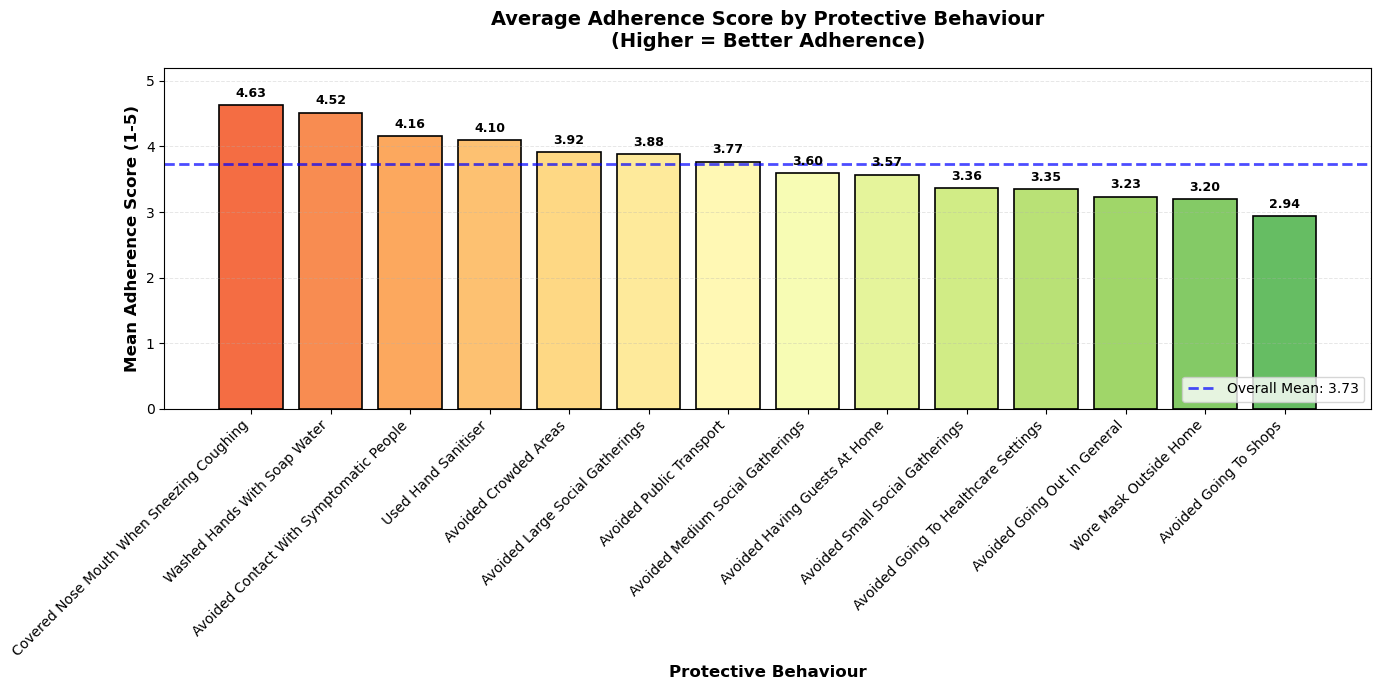

SUMMARY STATISTICS:
Mean adherence across all behaviours: 3.73
Median adherence across all behaviours: 3.68
Std. Dev: 0.50


In [5]:
# List of behaviour columns
behaviour_cols = [
    "wore_mask_outside_home",
    "used_hand_sanitiser",
    "covered_nose_mouth_when_sneezing_coughing",
    "avoided_contact_with_symptomatic_people",
    "avoided_going_out_in_general",
    "avoided_going_to_healthcare_settings",
    "avoided_public_transport",
    "avoided_small_social_gatherings",
    "avoided_medium_social_gatherings",
    "avoided_large_social_gatherings",
    "avoided_crowded_areas",
    "avoided_going_to_shops",
    "washed_hands_with_soap_water",
    "avoided_having_guests_at_home"
]

# Mean adherence score for each behaviour
behaviour_means = df_imputed[behaviour_cols].mean().sort_values(ascending=False)


print("AVERAGE ADHERENCE BY PROTECTIVE BEHAVIOUR")

print(behaviour_means)
print(f"\nHighest adherence: {behaviour_means.index[0]} ({behaviour_means.values[0]:.2f})")
print(f"Lowest adherence: {behaviour_means.index[-1]} ({behaviour_means.values[-1]:.2f})")

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 7))

# Create gradient color scheme: green (high adherence) to red (low adherence)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(behaviour_means)))
colors_sorted = [colors[i] for i in np.argsort(np.argsort(-behaviour_means.values))]

bars = ax.bar(range(len(behaviour_means)), behaviour_means.values, color=colors_sorted, edgecolor='black', linewidth=1.2)

# Customize plot
ax.set_xticks(range(len(behaviour_means)))
ax.set_xticklabels([label.replace("_", " ").title() for label in behaviour_means.index], 
                    rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Mean Adherence Score (1-5)', fontsize=12, fontweight='bold')
ax.set_xlabel('Protective Behaviour', fontsize=12, fontweight='bold')
ax.set_title('Average Adherence Score by Protective Behaviour\n(Higher = Better Adherence)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, 5.2)
ax.grid(axis='y', linestyle='--', alpha=0.3, linewidth=0.7)
ax.axhline(y=behaviour_means.mean(), color='blue', linestyle='--', linewidth=2, 
           label=f'Overall Mean: {behaviour_means.mean():.2f}', alpha=0.7)

# Add value labels on top of bars with better formatting
for i, (bar, value) in enumerate(zip(bars, behaviour_means.values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.08,
            f'{value:.2f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.legend(fontsize=10, loc='lower right')
plt.tight_layout()
plt.show()

# Summary statistics

print("SUMMARY STATISTICS:")

print(f"Mean adherence across all behaviours: {behaviour_means.mean():.2f}")
print(f"Median adherence across all behaviours: {behaviour_means.median():.2f}")
print(f"Std. Dev: {behaviour_means.std():.2f}")


In [ ]:
import pandas as pd
import numpy as np 

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
df_imputed = pd.read_csv("UGov_Data.csv", low_memory=False)

print("Original shape:", df_imputed.shape)

Original shape: (53833, 29)


ADHERENCE BY BEHAVIOURAL COST GROUP
Low-cost mean adherence:    4.417 (3 behaviours)
Medium-cost mean adherence: 3.855 (4 behaviours)
High-cost mean adherence:   3.403 (5 behaviours)

Low-cost behaviours: covered nose mouth when sneezing coughing, washed hands with soap water, used hand sanitiser
Medium-cost behaviours: avoided contact with symptomatic people, avoided crowded areas, avoided public transport, avoided having guests at home
High-cost behaviours: avoided small social gatherings, avoided medium social gatherings, avoided large social gatherings, avoided going out in general, avoided going to shops


C:\Users\indra\AppData\Local\Temp\ipykernel_12476\3929884584.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cost_means.index, fontsize=11, fontweight='bold')


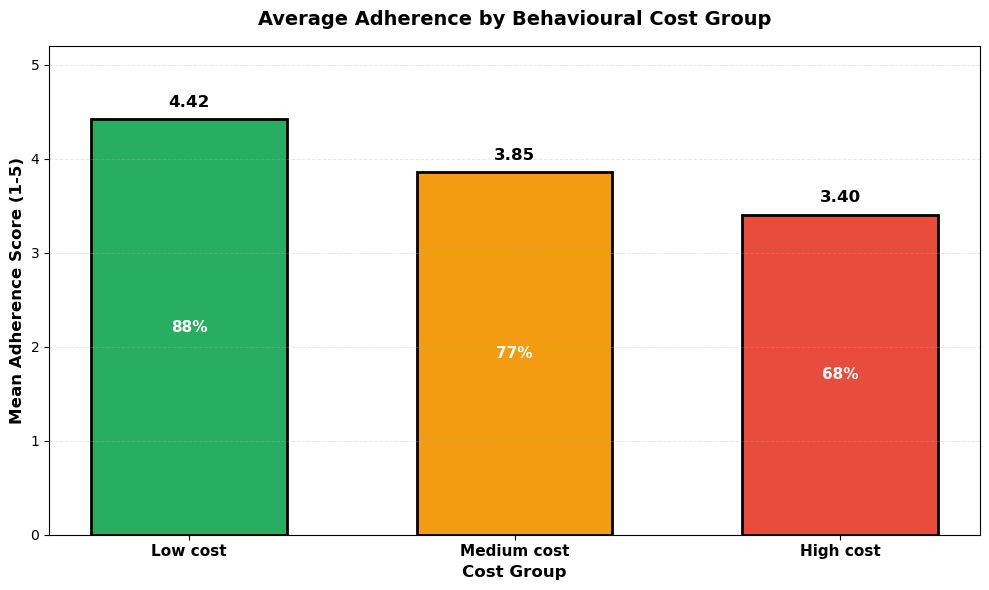

KEY INSIGHT:
People follow low-cost behaviours 29.8% MORE than high-cost behaviours
Difference: 1.014 points on the 1-5 scale


In [6]:
# independently defined cost groups
low_cost = [
    "covered_nose_mouth_when_sneezing_coughing",
    "washed_hands_with_soap_water",
    "used_hand_sanitiser"
]

medium_cost = [
    "avoided_contact_with_symptomatic_people",
    "avoided_crowded_areas",
    "avoided_public_transport",
    "avoided_having_guests_at_home"
]

high_cost = [
    "avoided_small_social_gatherings",
    "avoided_medium_social_gatherings",
    "avoided_large_social_gatherings",
    "avoided_going_out_in_general",
    "avoided_going_to_shops"
]

# mean adherence within each cost group
low_cost_mean = df_imputed[low_cost].mean().mean()
medium_cost_mean = df_imputed[medium_cost].mean().mean()
high_cost_mean = df_imputed[high_cost].mean().mean()


print("ADHERENCE BY BEHAVIOURAL COST GROUP")

print(f"Low-cost mean adherence:    {low_cost_mean:.3f} ({len(low_cost)} behaviours)")
print(f"Medium-cost mean adherence: {medium_cost_mean:.3f} ({len(medium_cost)} behaviours)")
print(f"High-cost mean adherence:   {high_cost_mean:.3f} ({len(high_cost)} behaviours)")

print("\nLow-cost behaviours:", ", ".join([b.replace("_", " ") for b in low_cost]))
print("Medium-cost behaviours:", ", ".join([b.replace("_", " ") for b in medium_cost]))
print("High-cost behaviours:", ", ".join([b.replace("_", " ") for b in high_cost]))

cost_means = pd.Series({
    "Low cost": low_cost_mean,
    "Medium cost": medium_cost_mean,
    "High cost": high_cost_mean
})

# Enhanced visualization
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#27ae60', '#f39c12', '#e74c3c']  # Green, Orange, Red
bars = ax.bar(cost_means.index, cost_means.values, color=colors, edgecolor='black', linewidth=2, width=0.6)

ax.set_title('Average Adherence by Behavioural Cost Group', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Mean Adherence Score (1-5)', fontsize=12, fontweight='bold')
ax.set_xlabel('Cost Group', fontsize=12, fontweight='bold')
ax.set_ylim(0, 5.2)
ax.grid(axis='y', linestyle='--', alpha=0.3, linewidth=0.7)

# Add value labels and percentage information
for bar, value in zip(bars, cost_means.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.1,
            f'{value:.2f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    # Add percentage of max
    pct = (value / 5) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, height / 2,
            f'{pct:.0f}%',
            ha='center', va='center', fontsize=11, fontweight='bold', color='white')

ax.set_xticklabels(cost_means.index, fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


print("KEY INSIGHT:")

diff = low_cost_mean - high_cost_mean
pct_diff = (diff / high_cost_mean) * 100
print(f"People follow low-cost behaviours {pct_diff:.1f}% MORE than high-cost behaviours")
print(f"Difference: {diff:.3f} points on the 1-5 scale")


C:\Users\indra\AppData\Local\Temp\ipykernel_12476\788333236.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_imputed.groupby("survey_week")[["low_cost_score", "medium_cost_score", "high_cost_score"]]


ADHERENCE BY COST GROUP OVER TIME (First 10 weeks):
             low_cost_score  medium_cost_score  high_cost_score
survey_week                                                    
week 1             4.405961           4.457091         4.319013
week 2             4.415838           4.479125         4.317893
week 3             4.379574           4.423403         4.264471
week 4             4.398406           4.452938         4.230279
week 5             4.393909           4.373635         4.209533
week 6             4.389218           4.312377         4.102367
week 7             4.358466           4.184772         3.877381
week 8             4.388778           4.008715         3.612749
week 9             4.428192           4.008209         3.535323
week 10            4.369343           3.783449         3.401189


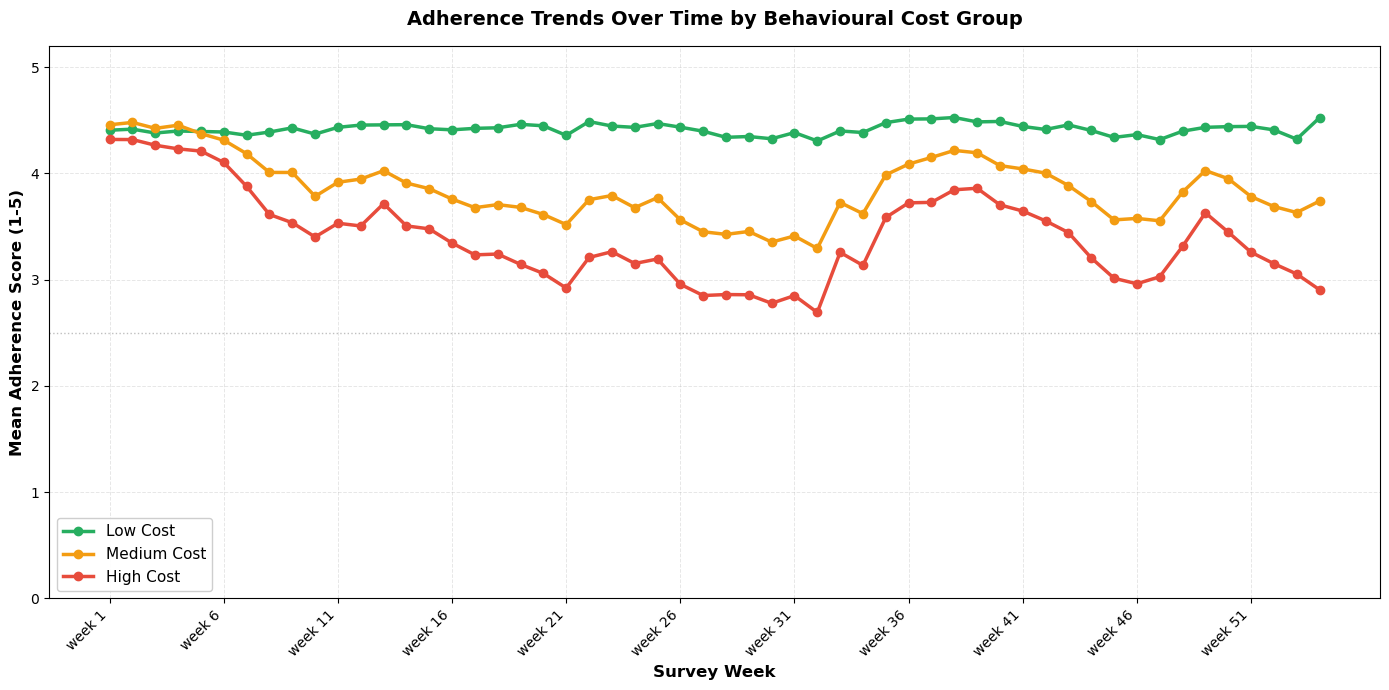

TREND ANALYSIS:
Initial adherence (week 1):
  Low cost:    4.41
  Medium cost: 4.46
  High cost:   4.32

Final adherence (week 54):
  Low cost:    4.52
  Medium cost: 3.74
  High cost:   2.90

Change (Initial → Final):
  Low cost:    +0.12
  Medium cost: -0.72
  High cost:   -1.41


In [7]:
# Create average score for each cost group per respondent
df_imputed["low_cost_score"] = df_imputed[low_cost].mean(axis=1)
df_imputed["medium_cost_score"] = df_imputed[medium_cost].mean(axis=1)
df_imputed["high_cost_score"] = df_imputed[high_cost].mean(axis=1)

# Group by survey week and sort in correct order
cost_by_week = (
    df_imputed.groupby("survey_week")[["low_cost_score", "medium_cost_score", "high_cost_score"]]
    .mean()
    .sort_index()
)

print("ADHERENCE BY COST GROUP OVER TIME (First 10 weeks):")
print(cost_by_week.head(10))

# Enhanced time series plot
fig, ax = plt.subplots(figsize=(14, 7))

colors = ['#27ae60', '#f39c12', '#e74c3c']
cost_by_week.plot(ax=ax, linewidth=2.5, marker='o', markersize=6, color=colors)

ax.set_title('Adherence Trends Over Time by Behavioural Cost Group', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Mean Adherence Score (1-5)', fontsize=12, fontweight='bold')
ax.set_xlabel('Survey Week', fontsize=12, fontweight='bold')
ax.set_ylim(0, 5.2)
ax.grid(True, linestyle='--', alpha=0.3, linewidth=0.7)

# Rename legend labels
ax.legend(['Low Cost', 'Medium Cost', 'High Cost'], fontsize=11, loc='best', framealpha=0.95)

# Show fewer x-axis labels so it looks cleaner
tick_positions = range(0, len(cost_by_week.index), 5)
ax.set_xticks(tick_positions)
ax.set_xticklabels(cost_by_week.index[tick_positions], rotation=45, ha='right')

ax.axhline(y=2.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

print("TREND ANALYSIS:")

print(f"Initial adherence ({cost_by_week.index[0]}):")
print(f"  Low cost:    {cost_by_week.iloc[0]['low_cost_score']:.2f}")
print(f"  Medium cost: {cost_by_week.iloc[0]['medium_cost_score']:.2f}")
print(f"  High cost:   {cost_by_week.iloc[0]['high_cost_score']:.2f}")

print(f"\nFinal adherence ({cost_by_week.index[-1]}):")
print(f"  Low cost:    {cost_by_week.iloc[-1]['low_cost_score']:.2f}")
print(f"  Medium cost: {cost_by_week.iloc[-1]['medium_cost_score']:.2f}")
print(f"  High cost:   {cost_by_week.iloc[-1]['high_cost_score']:.2f}")

print(f"\nChange (Initial → Final):")
low_change = cost_by_week.iloc[-1]['low_cost_score'] - cost_by_week.iloc[0]['low_cost_score']
med_change = cost_by_week.iloc[-1]['medium_cost_score'] - cost_by_week.iloc[0]['medium_cost_score']
high_change = cost_by_week.iloc[-1]['high_cost_score'] - cost_by_week.iloc[0]['high_cost_score']

print(f"  Low cost:    {low_change:+.2f}")
print(f"  Medium cost: {med_change:+.2f}")
print(f"  High cost:   {high_change:+.2f}")

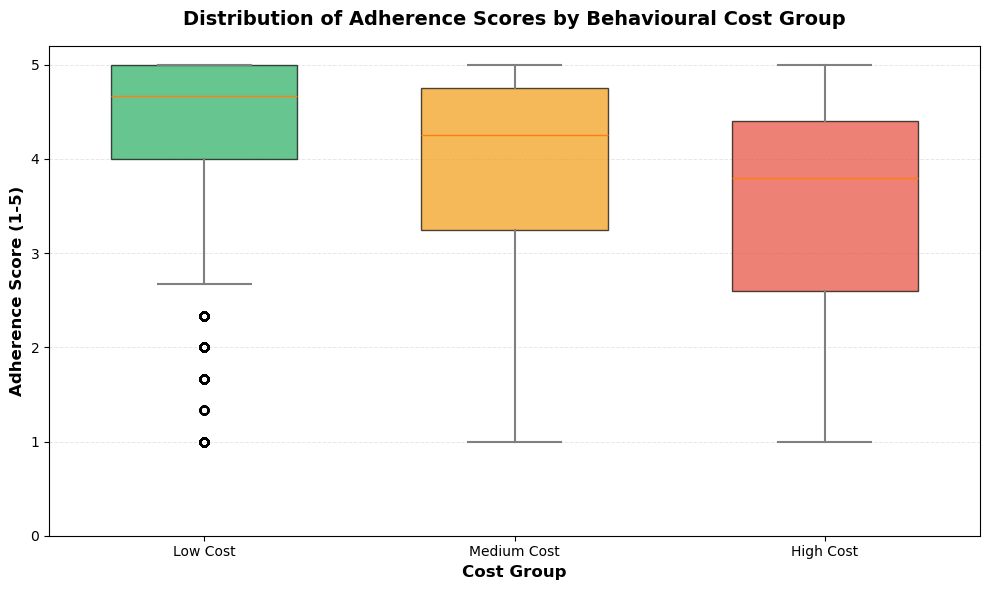

DISTRIBUTION STATISTICS:

Low Cost:
  Mean:      4.417
  Median:    4.667
  Std Dev:   0.743
  Min:       1.000
  Max:       5.000
  Q1 (25%):  4.000
  Q3 (75%):  5.000
  IQR:       1.000

Medium Cost:
  Mean:      3.855
  Median:    4.250
  Std Dev:   1.133
  Min:       1.000
  Max:       5.000
  Q1 (25%):  3.250
  Q3 (75%):  4.750
  IQR:       1.500

High Cost:
  Mean:      3.403
  Median:    3.800
  Std Dev:   1.283
  Min:       1.000
  Max:       5.000
  Q1 (25%):  2.600
  Q3 (75%):  4.400
  IQR:       1.800


In [8]:
plot_data = [
    df_imputed["low_cost_score"],
    df_imputed["medium_cost_score"],
    df_imputed["high_cost_score"]
]

fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot(plot_data, labels=["Low Cost", "Medium Cost", "High Cost"],
                 patch_artist=True, widths=0.6,
                 )

# Color the boxes
colors = ['#27ae60', '#f39c12', '#e74c3c']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Color whiskers and caps
for whisker in bp['whiskers']:
    whisker.set(linewidth=1.5, color='gray')
for cap in bp['caps']:
    cap.set(linewidth=1.5, color='gray')

ax.set_title('Distribution of Adherence Scores by Behavioural Cost Group', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Adherence Score (1-5)', fontsize=12, fontweight='bold')
ax.set_xlabel('Cost Group', fontsize=12, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.3, linewidth=0.7)
ax.set_ylim(0, 5.2)

# Add statistics text


plt.tight_layout()
plt.show()


print("DISTRIBUTION STATISTICS:")

for label, data in zip(["Low Cost", "Medium Cost", "High Cost"], plot_data):
    print(f"\n{label}:")
    print(f"  Mean:      {data.mean():.3f}")
    print(f"  Median:    {data.median():.3f}")
    print(f"  Std Dev:   {data.std():.3f}")
    print(f"  Min:       {data.min():.3f}")
    print(f"  Max:       {data.max():.3f}")
    print(f"  Q1 (25%):  {data.quantile(0.25):.3f}")
    print(f"  Q3 (75%):  {data.quantile(0.75):.3f}")
    print(f"  IQR:       {data.quantile(0.75) - data.quantile(0.25):.3f}")


In [9]:
# Main adherence behaviour columns only
behaviour_cols = [
    "wore_mask_outside_home",
    "used_hand_sanitiser",
    "covered_nose_mouth_when_sneezing_coughing",
    "avoided_contact_with_symptomatic_people",
    "avoided_going_out_in_general",
    "avoided_going_to_healthcare_settings",
    "avoided_public_transport",
    "avoided_small_social_gatherings",
    "avoided_medium_social_gatherings",
    "avoided_large_social_gatherings",
    "avoided_crowded_areas",
    "avoided_going_to_shops",
    "washed_hands_with_soap_water",
    "avoided_having_guests_at_home"
]

# Reshape to long format
df_long = df_imputed.melt(
    id_vars=[
        "record_id",
        "response_time",
        "survey_week",
        "age_group",
        "gender",
        "state",
        "household_size",
        "employment_status",
        "survey_weight",
        "would_self_isolate_if_symptomatic",
        "willingness_to_self_isolate_7days",
        "physical_contact_outside_household_count",
        "confidence_in_health_system_covid_response",
        "life_satisfaction_ladder",
        "government_handling_covid"
    ],
    value_vars=behaviour_cols,
    var_name="behaviour",
    value_name="adherence_score"
)

print(df_long.shape)
df_long.head()

(753662, 17)


,record_id,response_time,survey_week,age_group,gender,state,household_size,employment_status,survey_weight,would_self_isolate_if_symptomatic,willingness_to_self_isolate_7days,physical_contact_outside_household_count,confidence_in_health_system_covid_response,life_satisfaction_ladder,government_handling_covid,behaviour,adherence_score
0,0,2020-04-01 16:12:00,week 1,44,Male,Queensland,2,Not working - looking for work,0.678531,1,5,1,3,7,4,wore_mask_outside_home,2
1,1,2020-04-01 16:12:00,week 1,66,Male,Victoria,1,Retired,1.049460,1,5,6,3,7,4,wore_mask_outside_home,1
2,2,2020-04-01 16:13:00,week 1,22,Male,Victoria,3,Working part time (8-34 hours a week),1.271203,1,5,0,3,7,4,wore_mask_outside_home,5
3,3,2020-04-01 16:16:00,week 1,45,Male,New South Wales,3,Working full time (35 or more hours per week),0.936885,1,5,20,3,7,4,wore_mask_outside_home,5
4,4,2020-04-01 16:21:00,week 1,42,Female,Victoria,3,Working part time (8-34 hours a week),0.762042,1,4,0,3,7,4,wore_mask_outside_home,1


In [10]:
cost_map = {
    "covered_nose_mouth_when_sneezing_coughing": "low",
    "washed_hands_with_soap_water": "low",
    "used_hand_sanitiser": "low",

    "avoided_contact_with_symptomatic_people": "medium",
    "avoided_crowded_areas": "medium",
    "avoided_public_transport": "medium",
    "avoided_having_guests_at_home": "medium",
    "wore_mask_outside_home": "medium",

    "avoided_small_social_gatherings": "high",
    "avoided_medium_social_gatherings": "high",
    "avoided_large_social_gatherings": "high",
    "avoided_going_out_in_general": "high",
    "avoided_going_to_shops": "high",
    "avoided_going_to_healthcare_settings": "high"
}

df_long["cost_group"] = df_long["behaviour"].map(cost_map)

print(df_long[["behaviour", "cost_group"]].drop_duplicates().sort_values(["cost_group", "behaviour"]))
print(df_long["cost_group"].value_counts())

                                        behaviour cost_group
215332               avoided_going_out_in_general       high
269165       avoided_going_to_healthcare_settings       high
592163                     avoided_going_to_shops       high
484497            avoided_large_social_gatherings       high
430664           avoided_medium_social_gatherings       high
376831            avoided_small_social_gatherings       high
107666  covered_nose_mouth_when_sneezing_coughing        low
53833                         used_hand_sanitiser        low
645996               washed_hands_with_soap_water        low
161499    avoided_contact_with_symptomatic_people     medium
538330                      avoided_crowded_areas     medium
699829              avoided_having_guests_at_home     medium
322998                   avoided_public_transport     medium
0                          wore_mask_outside_home     medium
cost_group
high      322998
medium    269165
low       161499
Name: count, dtype: int

In [11]:
cost_group_summary = df_long.groupby("cost_group")["adherence_score"].agg(["count", "mean", "median", "std"])
print(cost_group_summary)



             count      mean  median       std
cost_group                                    
high        322998  3.393944     4.0  1.520497
low         161499  4.417006     5.0  0.974918
medium      269165  3.722776     4.0  1.531971


In [12]:
# Saving the YouGov data as csv
csv_name = 'UGov_Data_Long.csv'
df_long.to_csv(csv_name, index=False)